In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.style.use("ggplot")
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("../data/raw/Breast_Cancer.csv")

In [7]:
df.sample(5)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
3257,63,White,Married,T3,N2,IIIA,Moderately differentiated,2,Regional,80,Positive,Positive,6,4,56,Dead
3355,57,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,12,Negative,Negative,22,1,79,Alive
1163,61,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,18,Positive,Positive,21,2,81,Alive
68,58,Other,Divorced,T1,N1,IIA,Poorly differentiated,3,Regional,15,Positive,Positive,5,1,79,Alive
674,48,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,38,Positive,Positive,23,2,75,Alive


In [8]:
df.shape

(4024, 16)

In [9]:
df.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [11]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [12]:
df.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

1.Drop Survival Months:
This gives:

more realistic accuracy
better academic credibility
less cheating by model

2.drop outliers
3.Handle Imbalance
4.check this distributions
skewness
outliers from cell 23 and 24
5.
Dataset contains 4024 patient records.
2. No major missing values found.
3. Both categorical and numerical features exist.
4. Survival status is slightly imbalanced.
5. Tumor size and survival months show useful patterns.
6. Some numerical columns contain outliers.
7. Label encoding will be required for categorical columns.
8. Feature scaling may improve model performance.

In [14]:
df.duplicated().sum()

np.int64(1)

In [17]:
df["Status"].value_counts()

Status
Alive    3408
Dead      616
Name: count, dtype: int64

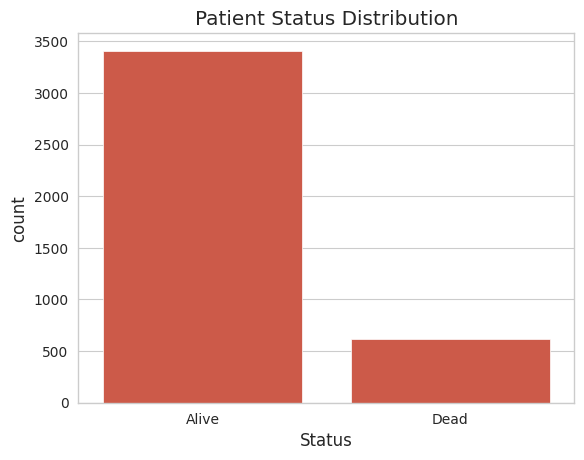

In [18]:
sns.countplot(x=df["Status"])
plt.title("Patient Status Distribution")
plt.show()

In [19]:
numerical_features = df.select_dtypes(include=np.number).columns

numerical_features

Index(['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive',
       'Survival Months'],
      dtype='object')

In [20]:
categorical_features = df.select_dtypes(include="object").columns

categorical_features

Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status', 'Status'],
      dtype='object')

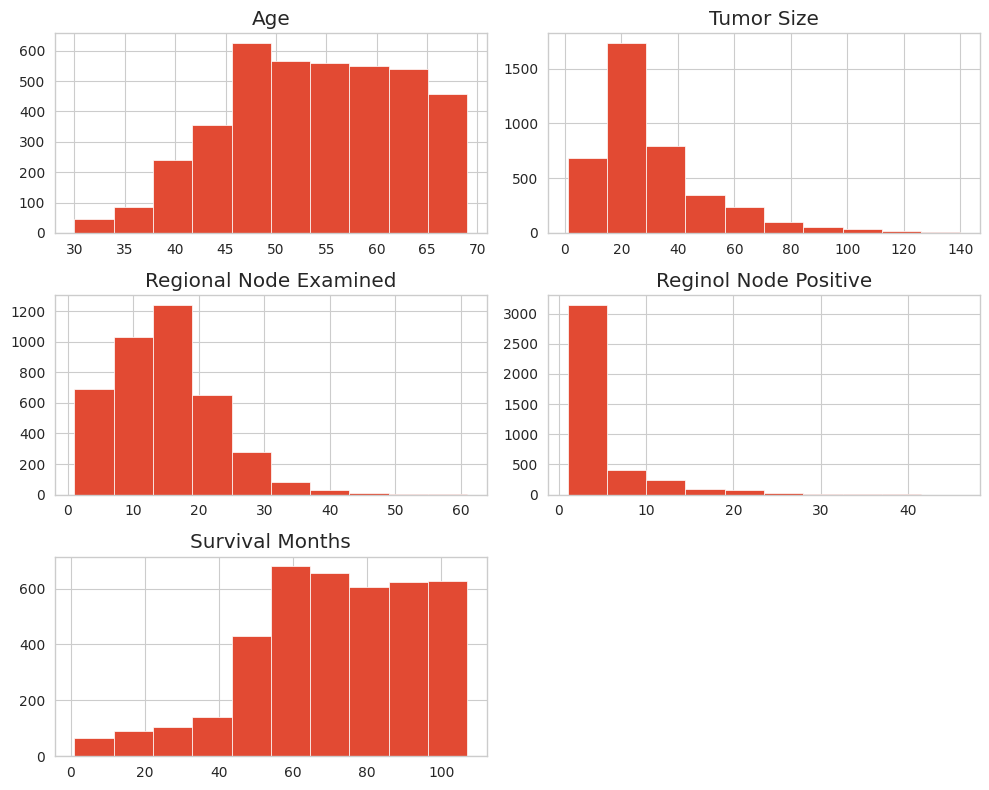

In [23]:
df[numerical_features].hist(figsize=(10,8))

plt.tight_layout()
plt.show()

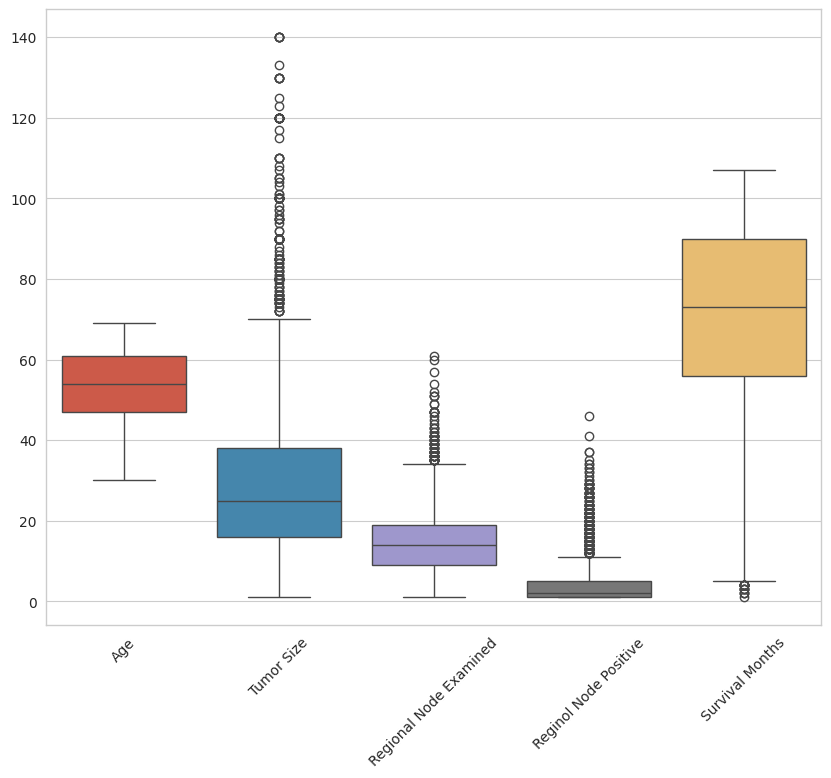

In [25]:
plt.figure(figsize=(10,8))

sns.boxplot(data=df[numerical_features])

plt.xticks(rotation=45)

plt.show()

In [26]:
le = LabelEncoder()

df["Status"] = le.fit_transform(df["Status"])

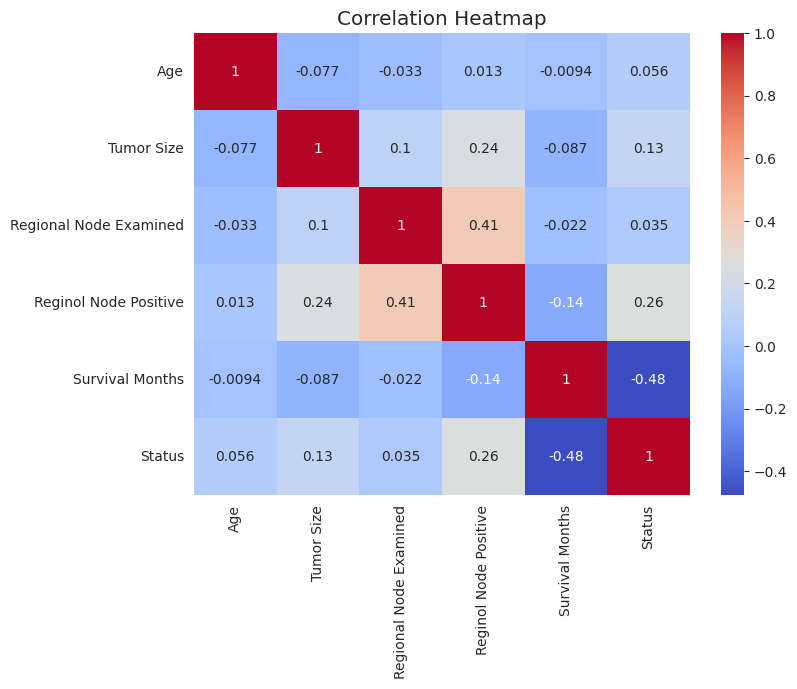

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_features.tolist() + ["Status"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

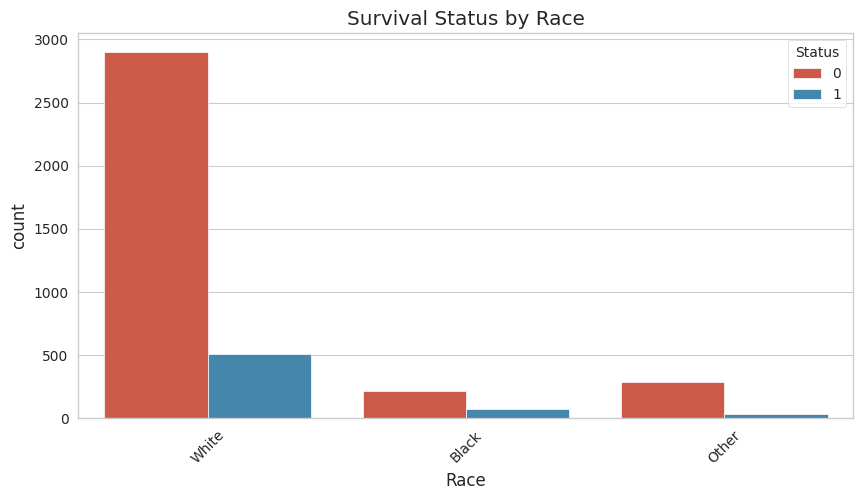

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Race",
    hue="Status",
    data=df
)

plt.title("Survival Status by Race")

plt.xticks(rotation=45)

plt.show()

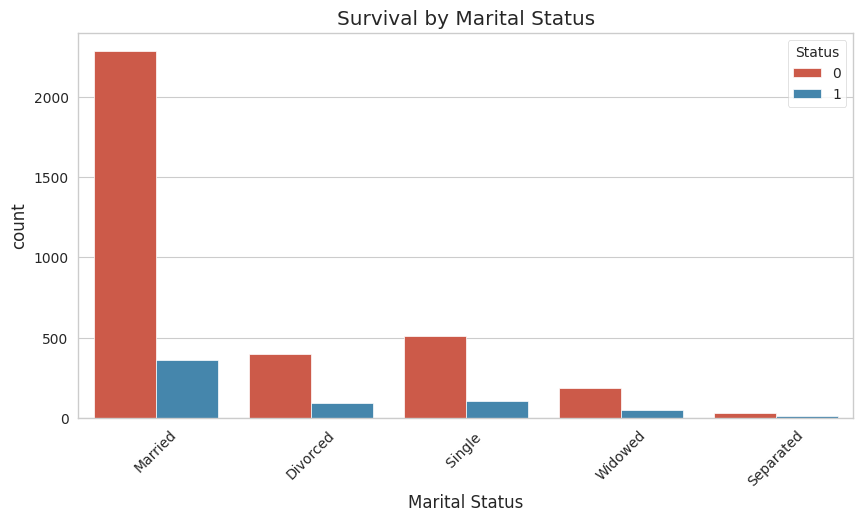

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Marital Status",
    hue="Status",
    data=df
)

plt.title("Survival by Marital Status")

plt.xticks(rotation=45)

plt.show()

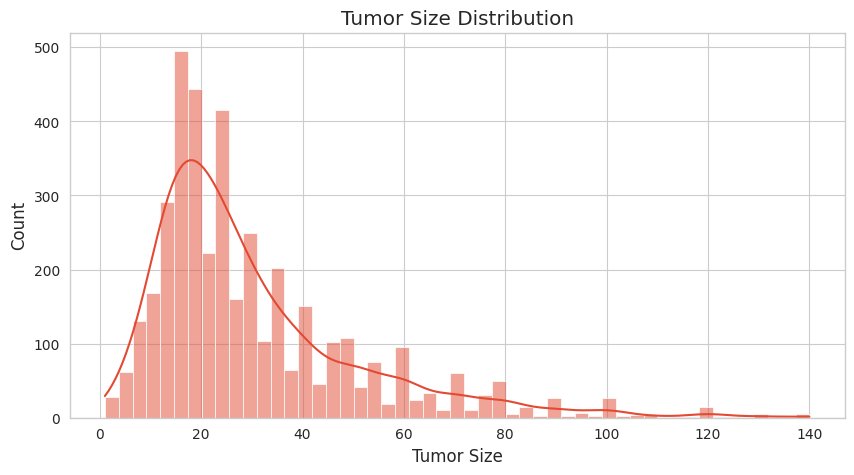

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Tumor Size"],
    kde=True
)

plt.title("Tumor Size Distribution")

plt.show()

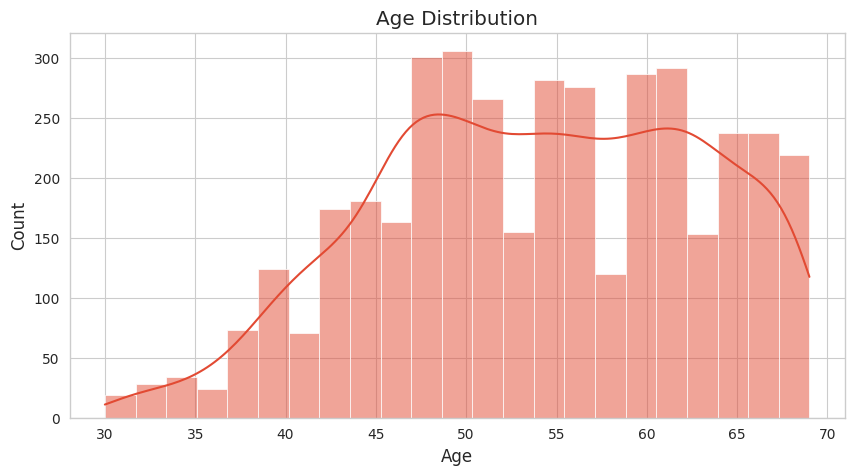

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Age"],
    kde=True
)

plt.title("Age Distribution")

plt.show()

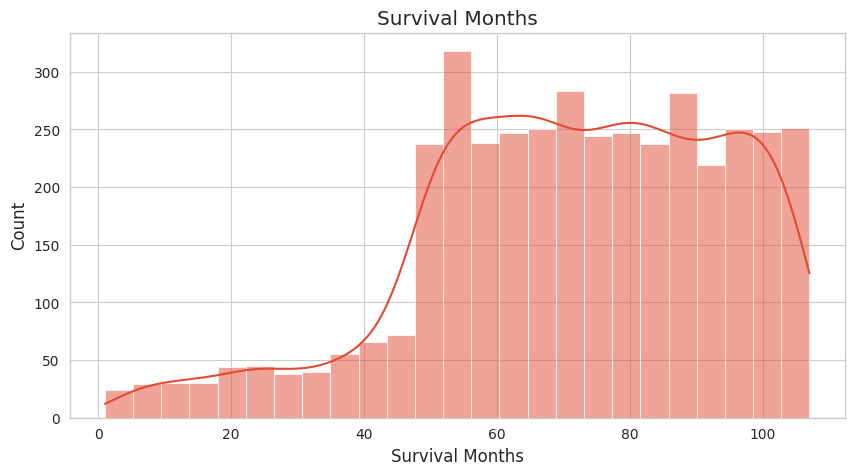

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Survival Months"],
    kde=True
)

plt.title("Survival Months")

plt.show()

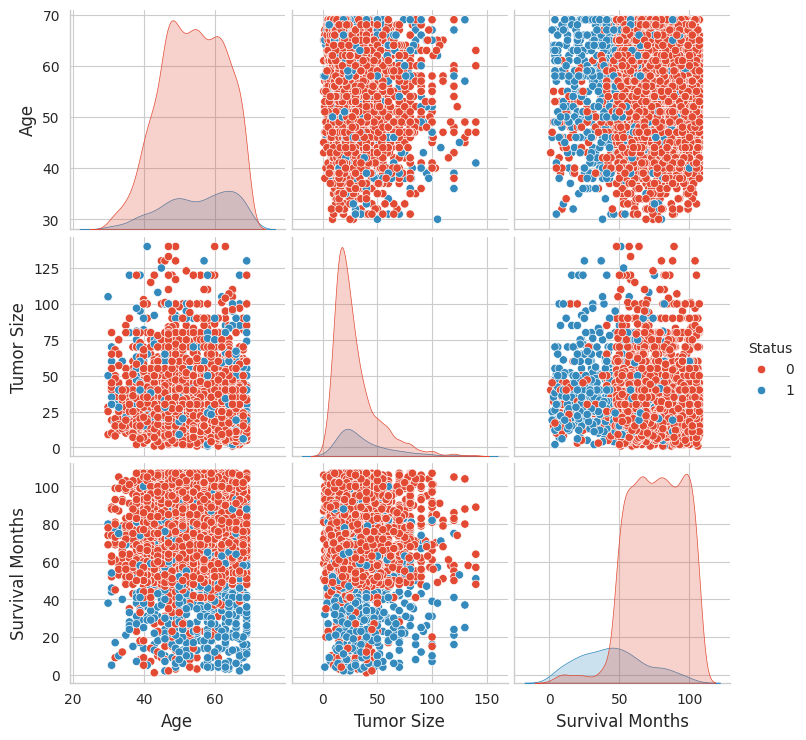

In [34]:
sns.pairplot(
    df[
        [
            "Age",
            "Tumor Size",
            "Survival Months",
            "Status"
        ]
    ],
    hue="Status"
)

plt.show()

In [35]:
(df["Status"].value_counts(normalize=True)) * 100

Status
0    84.691849
1    15.308151
Name: proportion, dtype: float64